# 05 · Cómo mejoramos la búsqueda dentro de los informes

**Qué pregunta responde este cuaderno.** Cuando alguien pregunta algo sobre un informe anual, ¿el buscador
encuentra el párrafo que de verdad lo responde? Un informe 10-K tiene cientos de páginas y el agente no puede
leerlas enteras: primero busca unos pocos fragmentos y después redacta la respuesta solo con ellos. Si la
búsqueda trae el párrafo equivocado, la respuesta será mala por muy bueno que sea el modelo.

**Por qué importa.** Aquí probamos cuatro versiones del buscador, de la más simple a la más elaborada, y medimos
cuántas veces acierta cada una. Así sabemos qué mejoras merecen la pena y cuáles no, en vez de suponerlo.

**Cómo se mide.** Tenemos 13 preguntas de las que conocemos de antemano el párrafo correcto — lo llamamos
*ancla*. Para cada versión del buscador contamos en cuántas de esas 13 el párrafo correcto aparece entre los
**5 primeros** resultados. Esa cuenta es el **recall@5** (aciertos sobre 13 mirando solo los cinco primeros
resultados). Un acierto exige además que el fragmento sea de la empresa, el ejercicio y la sección correctos.

---

*Detalle técnico (no hace falta para entender el cuaderno).* Requisitos R08 y R11
([01](../docs/01_requisitos_y_contratos.md)) · Guía: [11](../docs/11_skill_mejora_retrieval.md) · teoría:
[04](../docs/04_teoria_rag_retrieval.md). Entradas: `golden/golden_propio.jsonl` y el índice FAISS; salidas:
`resultados/retrieval/`. El cuaderno se abre y se ejecuta solo, sin ejecutar antes ningún otro. Con
`EJECUTAR = False` **no llama a ninguna API**: la reescritura de consultas reutiliza la caché ya guardada en
`resultados/cache/reescrituras.json`. El modelo de la reescritura es `config.MODELO_ID`
(`openrouter:inclusionai/ling-3.0-flash-fin:free` por defecto).


In [1]:
# Arranque: usa el kernel env_agentes y las rutas del paquete.
import sys
import pathlib
import json
import pandas as pd
from IPython.display import display

RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ / "src"))
from agente10k import config, datos, evaluacion, retrieval, herramientas

print("Python:", sys.executable)


Python: C:\Users\Usuario\Downloads\10k-financial-agent\.venv\Scripts\python.exe


In [2]:
# EJECUTAR=False (valor de entrega, regla 8 de CLAUDE.md): el cuaderno no llama a ninguna API.
# Los pasos locales funcionan igual y la reescritura de consultas se sirve de la caché ya
# guardada en resultados/cache/reescrituras.json. Poner True solo para pedir reescrituras nuevas.
EJECUTAR = False
REUTILIZAR_RANKINGS = True  # False repite búsquedas locales; conserva la caché LLM.
RUTA_PREDICCIONES_AGENTE = config.RESULTADOS / "final" / "predicciones.jsonl"

if not (config.MODELO_ID.startswith("openrouter:") and config.MODELO_ID.endswith(":free")):
    raise ValueError("El notebook 05 requiere un modelo OpenRouter :free. "
                     "Revisa AGENTE10K_MODELO y reinicia el kernel.")

# No se carga ni se muestra la clave aquí: reescribir() la leerá de .env
# únicamente si EJECUTAR=True y falta una entrada válida de la caché.
golden = evaluacion.cargar_golden(config.GOLDEN / "golden_propio.jsonl")
con_ancla = [p for p in golden if p.get("ancla_texto")]
DIRECTORIO = evaluacion.preparar_retrieval(golden)
print(f"Golden: {len(golden)} preguntas; retrieval: {len(con_ancla)} con ancla.")
print("Anclas no indexables: 0. Configuración fijada antes de medir.")
print("Resultados de este experimento:", DIRECTORIO)
print("Modelo de reescritura:", config.MODELO_ID, "| temperatura:", config.TEMPERATURA)
print("API habilitada:", EJECUTAR)
print("n_cand:", config.RETRIEVAL_N_CAND, "| constante RRF:", config.RETRIEVAL_K_RRF)


Golden: 20 preguntas; retrieval: 13 con ancla.
Anclas no indexables: 0. Configuración fijada antes de medir.
Resultados de este experimento: C:\Users\Usuario\Downloads\10k-financial-agent\resultados\retrieval\b7a7122745d3
Modelo de reescritura: openrouter:inclusionai/ling-3.0-flash-fin:free | temperatura: 0
API habilitada: False
n_cand: 20 | constante RRF: 60


## Dos maneras de buscar, y por qué las juntamos

| Forma de buscar | Cómo funciona | Dónde brilla | Dónde falla |
| --- | --- | --- | --- |
| **Por significado** (búsqueda *densa*, con *embeddings*: cada texto se convierte en una lista de números que resume su sentido) | Compara el sentido de la pregunta con el de cada párrafo | Encuentra el párrafo aunque no comparta ni una palabra con la pregunta | Se despista con el vocabulario financiero y no distingue una empresa de otra |
| **Por palabras** (*BM25*: el buscador clásico de toda la vida, que premia las palabras poco frecuentes que comparten pregunta y párrafo) | Cuenta coincidencias literales | Cuando la pregunta usa las palabras exactas del informe | Cuando el informe dice lo mismo con otras palabras |

Ninguna gana siempre, así que las **combinamos**: cada buscador ordena sus resultados y después se fusionan las
dos listas dando prioridad a lo que ambas colocan arriba (esa fusión se llama *RRF*).

## La escalera: cuatro peldaños, uno encima de otro

| Peldaño | Qué añade | En una frase |
| --- | --- | --- |
| **1. Denso** | Nada: la pregunta tal cual, en español | El punto de partida |
| **2. + filtro** | Empresa, ejercicio y sección | Deja de competir con los otros 47 documentos del corpus |
| **3. + BM25** | La búsqueda por palabras, fusionada con la anterior | Rescata los párrafos que el significado no ve |
| **4. + reescritura** | El modelo convierte la pregunta en una consulta de búsqueda en inglés | Habla el idioma del informe |

Las 13 preguntas son siempre las mismas en todos los peldaños; son las del golden propio que tienen ancla.

### Las 13 preguntas con las que se mide todo


In [3]:
display(pd.DataFrame([
    {"id": p["id"], "familia": p["familia"], "empresa": p["ticker"],
     "ejercicio": p["fiscal_year"], "sección": p.get("item_esperado"), "pregunta": p["pregunta"]}
    for p in con_ancla
]).set_index("id"))


,familia,empresa,ejercicio,sección,pregunta
id,,,,,
g3-008,extractiva,MSFT,2025,1A,"Según su 10-K de FY2025, ¿qué dice Microsoft s..."
g3-009,extractiva,NVDA,2025,1A,¿Qué riesgo declara NVIDIA en FY2025 por depen...
g3-010,extractiva,AAPL,2024,7A,¿Cómo describe Apple su exposición al riesgo d...
g3-011,extractiva,AMZN,2025,7,¿Qué dice la dirección de Amazon en FY2025 sob...
g3-012,extractiva,GOOGL,2025,1A,¿Qué riesgo regulatorio en materia de competen...
g3-013,extractiva,META,2024,8,¿Qué indica Meta en sus estados financieros de...
g3-014,comparativa,MSFT,2025,7,¿Cómo evolucionó los ingresos totales de MSFT ...
g3-015,comparativa,NVDA,2025,7,¿Cómo evolucionó los ingresos totales de NVDA ...
g3-016,comparativa,GOOGL,2025,7,¿Cómo evolucionó los ingresos totales de GOOGL...


### Cómo leer las tablas que vienen

Un **acierto** significa que el párrafo correcto (el ancla) aparece entre los primeros resultados **y** pertenece
a la empresa, el ejercicio y la sección esperados. Encontrarlo por casualidad en otro documento no cuenta.

Dos matices que conviene tener presentes al leer los números:

- En los peldaños 2 y 3 los filtros (empresa, ejercicio, sección) se **copian de la hoja de respuestas**. Se les
  llama filtros *oráculo* y miden **el techo** de esa mejora, no la habilidad del agente para deducirlos solo.
- En el peldaño 4 no hay oráculo: el modelo deduce los filtros de la propia pregunta. Es el único peldaño que
  refleja lo que el agente hace de verdad en producción.


## 1. Paso 0: búsqueda densa y recall@k de partida

Guía: [11 §3–§4](../docs/11_skill_mejora_retrieval.md)

In [4]:
# Comprueba con dos preguntas reales que el nuevo camino denso conserva
# exactamente el ranking del baseline, incluidos los empates de FAISS.
for pregunta in con_ancla[:2]:
    original = retrieval.buscar_denso(pregunta["pregunta"], k=20)
    nuevo = retrieval.buscar_hibrido([pregunta["pregunta"]], k=20, usar_bm25=False)
    assert [d["chunk_id"] for d in original] == [d["chunk_id"] for d in nuevo]
print("Equivalencia con el baseline comprobada en dos preguntas.")

paso0 = evaluacion.medir_retrieval(golden, "0_denso", DIRECTORIO,
                                  reutilizar=REUTILIZAR_RANKINGS)
display(pd.DataFrame([evaluacion.resumir_retrieval(paso0, golden)]))
detalle0 = pd.DataFrame(evaluacion.detalle_retrieval(paso0, golden)).merge(
    pd.DataFrame(con_ancla)[["id", "pregunta"]], on="id", validate="one_to_one")
with pd.option_context("display.max_colwidth", None):
    display(detalle0[["id", "pregunta", "item", "rango", "n_relevantes", "presente"]])
print("Consulta original, sin filtros. Recall@5:", evaluacion.recall_at_k(paso0, golden))


C:\Users\Usuario\Downloads\10k-financial-agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3879.12it/s]

Equivalencia con el baseline comprobada en dos preguntas.


,n,no_indexables,mrr@10,ms_busqueda,ms_reescritura,fallos_reescritura,reintentos_reescritura,usd_reescritura,aciertos@1,recall@1,aciertos@3,recall@3,aciertos@5,recall@5,aciertos@10,recall@10
0,13,0,0.038462,26.180077,0.0,0,0,0.0,0/13,0.0,0/13,0.0,2/13,0.153846,2/13,0.153846


,id,pregunta,item,rango,n_relevantes,presente
0,g3-008,"Según su 10-K de FY2025, ¿qué dice Microsoft sobre el uso indebido de sus sistemas de IA por parte de terceros?",1A,NaN,1,True
1,g3-009,¿Qué riesgo declara NVIDIA en FY2025 por depender de un número reducido de proveedores de fabricación?,1A,NaN,1,True
2,g3-010,¿Cómo describe Apple su exposición al riesgo de tipo de cambio en FY2024?,7A,NaN,1,True
3,g3-011,¿Qué dice la dirección de Amazon en FY2025 sobre la evolución de AWS?,7,4.0,1,True
4,g3-012,¿Qué riesgo regulatorio en materia de competencia declara Alphabet en FY2025?,1A,NaN,1,True
5,g3-013,¿Qué indica Meta en sus estados financieros de FY2024 sobre sus obligaciones contractuales o arrendamientos?,8,NaN,1,True
6,g3-014,"¿Cómo evolucionó los ingresos totales de MSFT entre los ejercicios fiscales 2024 y 2025, y qué explica la dirección al respecto?",7,NaN,1,True
7,g3-015,"¿Cómo evolucionó los ingresos totales de NVDA entre los ejercicios fiscales 2024 y 2025, y qué explica la dirección al respecto?",7,NaN,1,True
8,g3-016,"¿Cómo evolucionó los ingresos totales de GOOGL entre los ejercicios fiscales 2024 y 2025, y qué explica la dirección al respecto?",7,NaN,1,True
9,g3-017,"¿Cómo evolucionó el gasto en I+D de META entre los ejercicios fiscales 2024 y 2025, y qué explica la dirección al respecto?",7,NaN,1,True


Consulta original, sin filtros. Recall@5: 0.15384615384615385


**Qué nos dice esto:** con la pregunta tal cual, en español y sin filtros, el buscador solo coloca el párrafo
correcto entre los cinco primeros en **2 de 13** preguntas. Es el punto de partida, y es malo: no porque el
buscador esté roto, sino porque compite contra los 48 documentos del corpus a la vez.


## 2. Paso 1: filtro por metadatos

Guía: [11 §5](../docs/11_skill_mejora_retrieval.md)

In [5]:
# Los filtros oráculo vienen del golden: miden el potencial del filtro,
# no la capacidad del agente de inferir empresa, ejercicio y sección.
paso1 = evaluacion.medir_retrieval(golden, "1_filtro", DIRECTORIO,
                                  reutilizar=REUTILIZAR_RANKINGS)
display(pd.DataFrame([
    {"paso": "0_denso", **evaluacion.resumir_retrieval(paso0, golden)},
    {"paso": "1_filtro", **evaluacion.resumir_retrieval(paso1, golden)},
]))
meta = retrieval._leer_metadatos_cache()
candidatos = pd.DataFrame([
    {"id": p["id"], **evaluacion.filtros_oraculo(p),
     "n_candidatos": len(retrieval.candidatos(**evaluacion.filtros_oraculo(p)))}
    for p in con_ancla
])
candidatos["aleatorio@5"] = candidatos["n_candidatos"].map(
    lambda n: min(1, 5 / n) if n else 0)
display(candidatos)
print("Con búsqueda exacta, filtrar antes o después de ordenar TODO da el mismo top-k.")
print("El filtro sí debe preceder al recorte top-20 del híbrido.")


,paso,n,no_indexables,mrr@10,ms_busqueda,ms_reescritura,fallos_reescritura,reintentos_reescritura,usd_reescritura,aciertos@1,recall@1,aciertos@3,recall@3,aciertos@5,recall@5,aciertos@10,recall@10
0,0_denso,13,0,0.038462,26.180077,0.0,0,0,0.0,0/13,0.000000,0/13,0.000000,2/13,0.153846,2/13,0.153846
1,1_filtro,13,0,0.296154,28.352000,0.0,0,0,0.0,3/13,0.230769,4/13,0.307692,4/13,0.307692,7/13,0.538462


,id,ticker,fiscal_year,item,n_candidatos,aleatorio@5
0,g3-008,MSFT,2025,1A,32,0.156250
1,g3-009,NVDA,2025,1A,49,0.102041
2,g3-010,AAPL,2024,7A,2,1.000000
3,g3-011,AMZN,2025,7,25,0.200000
4,g3-012,GOOGL,2025,1A,39,0.128205
5,g3-013,META,2024,8,75,0.066667
6,g3-014,MSFT,2025,7,26,0.192308
7,g3-015,NVDA,2025,7,23,0.217391
8,g3-016,GOOGL,2025,7,29,0.172414
9,g3-017,META,2025,7,36,0.138889


Con búsqueda exacta, filtrar antes o después de ordenar TODO da el mismo top-k.
El filtro sí debe preceder al recorte top-20 del híbrido.


**Qué nos dice esto:** limitar la búsqueda a la empresa, el ejercicio y la sección correctos **duplica** los
aciertos, de 2 a **4 de 13**, sin tocar el buscador. Es la mejora más barata de todo el cuaderno. Recuerda que
estos filtros vienen del golden: miden el techo del filtro, no lo que el agente sabe deducir.


## 3. Paso 2: BM25 + denso con RRF

Guía: [11 §6](../docs/11_skill_mejora_retrieval.md)

In [6]:
# BM25 usa IDF global, la misma tokenización en corpus y consultas,
# y descarta puntuaciones <= 0. RRF combina posiciones con pesos iguales.
paso2 = evaluacion.medir_retrieval(golden, "2_bm25", DIRECTORIO,
                                  reutilizar=REUTILIZAR_RANKINGS)
solo_bm25 = evaluacion.medir_retrieval(golden, "d_solo_bm25", DIRECTORIO,
                                       reutilizar=REUTILIZAR_RANKINGS)
display(pd.DataFrame([
    {"paso": "1_filtro", **evaluacion.resumir_retrieval(paso1, golden)},
    {"paso": "2_bm25", **evaluacion.resumir_retrieval(paso2, golden)},
    {"paso": "d_solo_bm25", **evaluacion.resumir_retrieval(solo_bm25, golden)},
]))
ruta_techos = DIRECTORIO / "techos.jsonl"
if REUTILIZAR_RANKINGS and ruta_techos.is_file():
    techos = evaluacion.cargar_golden(ruta_techos)
else:
    techos = evaluacion.techos_retrieval(golden)
    evaluacion.guardar_golden(techos, ruta_techos)
display(pd.DataFrame(techos))
print("Las preguntas siguen en español: BM25 puede aportar poco hasta la reescritura.")
print("Si el ancla no está en ninguno de los dos top-20, RRF no puede recuperarla.")


,paso,n,no_indexables,mrr@10,ms_busqueda,ms_reescritura,fallos_reescritura,reintentos_reescritura,usd_reescritura,aciertos@1,recall@1,aciertos@3,recall@3,aciertos@5,recall@5,aciertos@10,recall@10
0,1_filtro,13,0,0.296154,28.352000,0.0,0,0,0.0,3/13,0.230769,4/13,0.307692,4/13,0.307692,7/13,0.538462
1,2_bm25,13,0,0.241758,27.018231,0.0,0,0,0.0,2/13,0.153846,3/13,0.230769,5/13,0.384615,6/13,0.461538
2,d_solo_bm25,13,0,0.135989,0.670154,0.0,0,0,0.0,1/13,0.076923,1/13,0.076923,2/13,0.153846,7/13,0.538462


,id,item,n_candidatos,aleatorio@5,techo_filtro,hit_denso@20,hit_bm25@20,techo_hibrido
0,g3-008,1A,32,0.156250,True,True,False,True
1,g3-009,1A,49,0.102041,True,True,False,True
2,g3-010,7A,2,1.000000,True,True,True,True
3,g3-011,7,25,0.200000,True,True,True,True
4,g3-012,1A,39,0.128205,True,True,True,True
5,g3-013,8,75,0.066667,True,True,False,True
6,g3-014,7,26,0.192308,True,False,False,False
7,g3-015,7,23,0.217391,True,True,True,True
8,g3-016,7,29,0.172414,True,True,True,True
9,g3-017,7,36,0.138889,True,True,True,True


Las preguntas siguen en español: BM25 puede aportar poco hasta la reescritura.
Si el ancla no está en ninguno de los dos top-20, RRF no puede recuperarla.


**Qué nos dice esto:** sumar la búsqueda por palabras a la búsqueda por significado añade un acierto más,
**5 de 13**. La fila `d_solo_bm25` enseña lo importante: BM25 **por su cuenta** se queda en 2 de 13. El valor
está en combinar las dos formas de buscar, no en cambiar una por otra.


## 4. Paso 3: reescritura de la consulta con el LLM

Guía: [11 §7](../docs/11_skill_mejora_retrieval.md)

In [7]:
# Única celda que puede llamar a OpenRouter: solo con EJECUTAR=True
# y para preguntas sin caché válida; los fallos se reintentan. Nunca se imprime la clave.
# Usa 1-3 consultas en inglés y filtros del modelo corregidos con entidades explícitas.
# Las comparativas buscan ambos ejercicios y fusionan sus rankings.
paso3 = None
try:
    paso3 = evaluacion.medir_retrieval(
        golden, "3_reescritura", DIRECTORIO,
        permitir_api=EJECUTAR, reutilizar=REUTILIZAR_RANKINGS,
    )
    rw_oraculo = evaluacion.medir_retrieval(
        golden, "d_rw_oraculo", DIRECTORIO,
        permitir_api=EJECUTAR, reutilizar=REUTILIZAR_RANKINGS,
    )
except retrieval.ReescrituraPendiente as exc:
    print(str(exc))
    print("Puedes continuar: la tabla final indicará que falta el paso 3.")
else:
    display(pd.DataFrame([{
        "id": f["id"], **f["reescritura"]["busqueda"],
        "fallo": f["reescritura"]["fallo"], "error": f["reescritura"]["error"],
        "ms": f["reescritura"]["ms"], "usd": f["reescritura"]["usd"],
        "intentos": f["reescritura"].get("intentos"),
        "ajustes_explicitos": f["reescritura"].get("ajustes_filtros"),
        "filtros_llm": f.get("filtros_llm"),
        "filtros": f["filtros"],
    } for f in paso3]))
    display(pd.DataFrame([
        {"paso": "3_reescritura", **evaluacion.resumir_retrieval(paso3, golden)},
        {"paso": "d_rw_oraculo", **evaluacion.resumir_retrieval(rw_oraculo, golden)},
    ]))
    print("USD vacío significa coste no comunicado; no se sustituye por cero.")
    print("El tiempo de reescritura se guarda aparte del tiempo de búsqueda.")
    print("En comparativas, oráculo usa el FY reciente; el paso 3 busca ambos FY.")


,id,consultas,ticker,fiscal_years,item,fallo,error,ms,usd,intentos,ajustes_explicitos,filtros_llm,filtros
0,g3-008,[misuse of AI systems by third parties unautho...,MSFT,[2025],None,False,None,3403.53,0.0,1,{},"{'ticker': 'ok', 'fiscal_years': 'ok', 'item':...","{'ticker': 'ok', 'fiscal_years': 'ok', 'item':..."
1,g3-009,[dependence on a limited number of suppliers m...,NVDA,[2025],1A,False,None,1733.07,0.0,1,{},"{'ticker': 'ok', 'fiscal_years': 'ok', 'item':...","{'ticker': 'ok', 'fiscal_years': 'ok', 'item':..."
2,g3-010,[foreign exchange risk exposure currency fluct...,AAPL,[2024],7A,False,None,2244.68,0.0,1,{},"{'ticker': 'ok', 'fiscal_years': 'ok', 'item':...","{'ticker': 'ok', 'fiscal_years': 'ok', 'item':..."
3,g3-011,[AWS revenue growth and business evolution dis...,AMZN,[2025],None,False,None,1422.62,0.0,1,{'fiscal_years': [2025]},"{'ticker': 'ok', 'fiscal_years': 'ausente', 'i...","{'ticker': 'ok', 'fiscal_years': 'ok', 'item':..."
4,g3-012,"[regulatory risk antitrust competition, compet...",GOOGL,[2025],1A,False,None,1694.30,0.0,1,{},"{'ticker': 'ok', 'fiscal_years': 'ok', 'item':...","{'ticker': 'ok', 'fiscal_years': 'ok', 'item':..."
5,g3-013,"[contractual obligations leases commitments, o...",META,[2024],8,False,None,1438.97,0.0,1,{},"{'ticker': 'ok', 'fiscal_years': 'ok', 'item':...","{'ticker': 'ok', 'fiscal_years': 'ok', 'item':..."
6,g3-014,"[total revenues fiscal year 2024 2025, revenue...",MSFT,"[2024, 2025]",None,False,None,1856.75,0.0,1,"{'fiscal_years': [2024, 2025]}","{'ticker': 'ok', 'fiscal_years': 'ausente', 'i...","{'ticker': 'ok', 'fiscal_years': 'ok', 'item':..."
7,g3-015,[NVDA total revenues fiscal year 2024 and fisc...,NVDA,"[2024, 2025]",None,False,None,4309.53,0.0,1,{},"{'ticker': 'ok', 'fiscal_years': 'ok', 'item':...","{'ticker': 'ok', 'fiscal_years': 'ok', 'item':..."
8,g3-016,[total revenues consolidated statements of inc...,GOOGL,"[2024, 2025]",7,False,None,2627.47,0.0,1,{},"{'ticker': 'ok', 'fiscal_years': 'ok', 'item':...","{'ticker': 'ok', 'fiscal_years': 'ok', 'item':..."
9,g3-017,[research and development expense trend fiscal...,META,"[2024, 2025]",None,False,None,2699.81,0.0,1,"{'fiscal_years': [2024, 2025]}","{'ticker': 'ok', 'fiscal_years': 'ausente', 'i...","{'ticker': 'ok', 'fiscal_years': 'ok', 'item':..."


,paso,n,no_indexables,mrr@10,ms_busqueda,ms_reescritura,fallos_reescritura,reintentos_reescritura,usd_reescritura,aciertos@1,recall@1,aciertos@3,recall@3,aciertos@5,recall@5,aciertos@10,recall@10
0,3_reescritura,13,0,0.262821,58.802923,2238.765385,0,0,0.0,2/13,0.153846,4/13,0.307692,5/13,0.384615,7/13,0.538462
1,d_rw_oraculo,13,0,0.375000,56.515692,2238.765385,0,0,0.0,3/13,0.230769,5/13,0.384615,6/13,0.461538,10/13,0.769231


USD vacío significa coste no comunicado; no se sustituye por cero.
El tiempo de reescritura se guarda aparte del tiempo de búsqueda.
En comparativas, oráculo usa el FY reciente; el paso 3 busca ambos FY.


**Qué nos dice esto:** pedirle al modelo que convierta la pregunta en una consulta de búsqueda en inglés **no
añade aciertos** (sigue en 5 de 13) y cuesta unos 2,2 segundos más por pregunta. Se conserva porque ordena algo
mejor los resultados y, sobre todo, porque es el único peldaño que deduce los filtros sin mirar las respuestas:
es el que el agente puede usar de verdad.


## 5. Tabla de la escalera y configuración final

Guía: [11 §8](../docs/11_skill_mejora_retrieval.md) · [11 §10](../docs/11_skill_mejora_retrieval.md)

In [8]:
# Regenera CSV y JSON desde los rankings guardados, sin nuevas llamadas.
# No se generan ficheros ni celdas Markdown.
tablas = evaluacion.exportar_retrieval(golden, DIRECTORIO)
for nombre in ("escalera", "por_item", "filtros", "cambios"):
    print(nombre)
    display(tablas[nombre])

resumen = json.loads((DIRECTORIO / "resumen.json").read_text(encoding="utf-8"))
print("Escalera completa sin fallos:", resumen["completo"], "| Pendientes:", resumen["pendientes"],
      "| Reescrituras fallidas:", resumen.get("fallos_reescritura", 0))
print("Configuración y resultados:", DIRECTORIO)

# Herramienta final lista para conectarla al sistema final del notebook 07.
# La instancia original search_filings y TOOLS conservan el baseline del 04.
search_filings_final = herramientas.crear_search_filings("final")
tools_retrieval_final = [
    search_filings_final if t.name == "search_filings" else t for t in herramientas.TOOLS
]
assert search_filings_final.name == herramientas.search_filings.name
assert list(search_filings_final.args) == list(herramientas.search_filings.args)
print("Herramienta híbrida preparada:", search_filings_final.name,
      "| argumentos:", list(search_filings_final.args))

# Diagnóstico dentro del agente solo si ya existen sus predicciones.
# Este notebook no ejecuta el agente ni necesita resultados del 04.
if RUTA_PREDICCIONES_AGENTE.is_file():
    predicciones = evaluacion.cargar_golden(RUTA_PREDICCIONES_AGENTE)
    diagnostico = evaluacion.diagnosticar_retrieval_agente(predicciones, golden)
    diagnostico.to_csv(DIRECTORIO / "diagnostico_agente.csv", index=False)
    display(diagnostico)
else:
    print("Diagnóstico del agente pendiente: todavía no hay predicciones en",
          RUTA_PREDICCIONES_AGENTE)


escalera


,paso,n,no_indexables,mrr@10,ms_busqueda,ms_reescritura,fallos_reescritura,reintentos_reescritura,usd_reescritura,aciertos@1,recall@1,aciertos@3,recall@3,aciertos@5,recall@5,aciertos@10,recall@10
0,0_denso,13,0,0.038462,26.180077,0.000000,0,0,0.0,0/13,0.000000,0/13,0.000000,2/13,0.153846,2/13,0.153846
1,1_filtro,13,0,0.296154,28.352000,0.000000,0,0,0.0,3/13,0.230769,4/13,0.307692,4/13,0.307692,7/13,0.538462
2,2_bm25,13,0,0.241758,27.018231,0.000000,0,0,0.0,2/13,0.153846,3/13,0.230769,5/13,0.384615,6/13,0.461538
3,3_reescritura,13,0,0.262821,58.802923,2238.765385,0,0,0.0,2/13,0.153846,4/13,0.307692,5/13,0.384615,7/13,0.538462
4,d_solo_bm25,13,0,0.135989,0.670154,0.000000,0,0,0.0,1/13,0.076923,1/13,0.076923,2/13,0.153846,7/13,0.538462
5,d_rw_oraculo,13,0,0.375000,56.515692,2238.765385,0,0,0.0,3/13,0.230769,5/13,0.384615,6/13,0.461538,10/13,0.769231


por_item


,paso,item,aciertos@5,recall@5
0,0_denso,1A,0/3,0.000000
1,0_denso,7,1/6,0.166667
2,0_denso,7A,0/1,0.000000
3,0_denso,8,1/3,0.333333
4,1_filtro,1A,0/3,0.000000
5,1_filtro,7,2/6,0.333333
6,1_filtro,7A,1/1,1.000000
7,1_filtro,8,1/3,0.333333
8,2_bm25,1A,1/3,0.333333
9,2_bm25,7,2/6,0.333333


filtros


,campo,estado,n,porcentaje
0,ticker,ok,13,100.000000
1,ticker,ausente,0,0.000000
2,ticker,erroneo,0,0.000000
3,fiscal_years,ok,13,100.000000
4,fiscal_years,ausente,0,0.000000
5,fiscal_years,erroneo,0,0.000000
6,item,ok,6,46.153846
7,item,ausente,6,46.153846
8,item,erroneo,1,7.692308


cambios


,antes,despues,id,rango_antes,rango_despues,cambio
0,0_denso,1_filtro,g3-008,NaN,11.0,igual
1,0_denso,1_filtro,g3-009,NaN,10.0,igual
2,0_denso,1_filtro,g3-010,NaN,1.0,ganada
3,0_denso,1_filtro,g3-011,4.0,1.0,igual
4,0_denso,1_filtro,g3-012,NaN,8.0,igual
5,0_denso,1_filtro,g3-013,NaN,16.0,igual
6,0_denso,1_filtro,g3-014,NaN,NaN,igual
7,0_denso,1_filtro,g3-015,NaN,20.0,igual
8,0_denso,1_filtro,g3-016,NaN,16.0,igual
9,0_denso,1_filtro,g3-017,NaN,8.0,igual


Escalera completa sin fallos: True | Pendientes: [] | Reescrituras fallidas: 0
Configuración y resultados: C:\Users\Usuario\Downloads\10k-financial-agent\resultados\retrieval\b7a7122745d3
Herramienta híbrida preparada: search_filings | argumentos: ['query', 'ticker', 'fiscal_year', 'item', 'k']


,id,llamada,recall_agente,ticker,fiscal_years,item
0,g3-008,1.0,True,ok,ok,ok
1,g3-009,1.0,True,ok,ausente,ausente
2,g3-009,2.0,True,ok,ausente,ausente
3,g3-009,3.0,True,ok,ausente,ausente
4,g3-009,4.0,True,ok,ausente,ok
5,g3-010,1.0,True,ok,ok,ok
6,g3-011,1.0,True,ausente,ok,ok
7,g3-012,1.0,True,ok,ok,ok
8,g3-013,1.0,True,erroneo,ausente,ausente
9,g3-014,1.0,True,ok,ok,ok


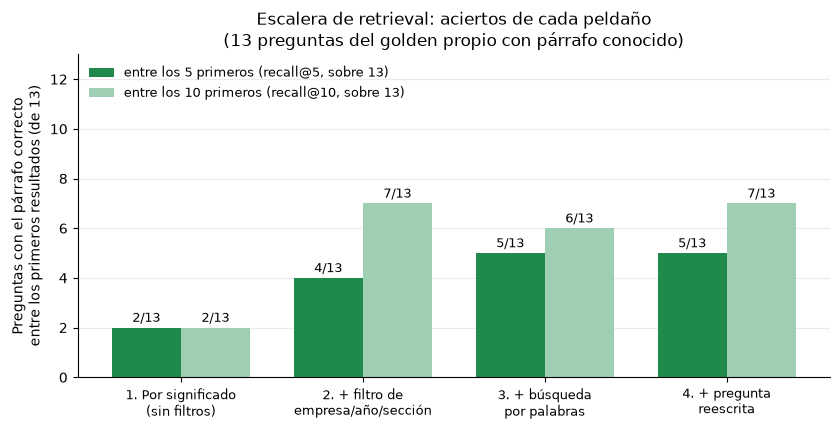

Techo medido con la reescritura ideal (diagnóstico, no es el sistema): 6/13 entre los 5 primeros y 10/13 entre los 10.
Tanda oficial 5976eb180c38: 0_denso 2/13 · 1_filtro 4/13 · 2_bm25 5/13 · 3_reescritura 5/13
Esta reejecución reproduce los mismos aciertos@5: True


In [9]:
# Gráfico oficial de la escalera: se lee de resumen.json, no hay ninguna cifra escrita a mano.
import matplotlib.pyplot as plt

ESCALERA = {
    "0_denso": "1. Por significado\n(sin filtros)",
    "1_filtro": "2. + filtro de\nempresa/año/sección",
    "2_bm25": "3. + búsqueda\npor palabras",
    "3_reescritura": "4. + pregunta\nreescrita",
}
_resumen_escalera = json.loads((DIRECTORIO / "resumen.json").read_text(encoding="utf-8"))
_pasos = {p["paso"]: p for p in _resumen_escalera["pasos"]}
_orden = [k for k in ESCALERA if k in _pasos]
_n = _pasos[_orden[0]]["n"]
_top5 = [int(_pasos[k]["aciertos@5"].split("/")[0]) for k in _orden]
_top10 = [int(_pasos[k]["aciertos@10"].split("/")[0]) for k in _orden]

fig, ax = plt.subplots(figsize=(8.5, 4.4))
_x = range(len(_orden))
_b5 = ax.bar([v - 0.19 for v in _x], _top5, width=0.38, color="#1f8a4c",
             label=f"entre los 5 primeros (recall@5, sobre {_n})")
_b10 = ax.bar([v + 0.19 for v in _x], _top10, width=0.38, color="#9ecfb2",
              label=f"entre los 10 primeros (recall@10, sobre {_n})")
ax.bar_label(_b5, labels=[f"{v}/{_n}" for v in _top5], padding=2, fontsize=9)
ax.bar_label(_b10, labels=[f"{v}/{_n}" for v in _top10], padding=2, fontsize=9)
ax.set_xticks(list(_x))
ax.set_xticklabels([ESCALERA[k] for k in _orden], fontsize=9)
ax.set_ylabel(f"Preguntas con el párrafo correcto\nentre los primeros resultados (de {_n})")
ax.set_ylim(0, _n)
ax.set_title("Escalera de retrieval: aciertos de cada peldaño\n"
             "(13 preguntas del golden propio con párrafo conocido)")
ax.legend(loc="upper left", fontsize=9, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

_techo = _pasos.get("d_rw_oraculo")
if _techo:
    print(f"Techo medido con la reescritura ideal (diagnóstico, no es el sistema): "
          f"{_techo['aciertos@5']} entre los 5 primeros y {_techo['aciertos@10']} entre los 10.")

# Contraste con la tanda oficial citada en la memoria (5976eb180c38). Cada versión del código
# genera su propia carpeta con huella; los aciertos deben coincidir aunque cambien los tiempos.
HUELLA_OFICIAL = "5976eb180c38"
_ruta_oficial = config.RESULTADOS / "retrieval" / HUELLA_OFICIAL / "resumen.json"
if _ruta_oficial.is_file() and DIRECTORIO.name != HUELLA_OFICIAL:
    _of = {p["paso"]: p for p in json.loads(_ruta_oficial.read_text(encoding="utf-8"))["pasos"]}
    _iguales = all(_of[k]["aciertos@5"] == _pasos[k]["aciertos@5"] for k in _orden if k in _of)
    print(f"Tanda oficial {HUELLA_OFICIAL}: "
          + " · ".join(f"{k} {_of[k]['aciertos@5']}" for k in _orden if k in _of))
    print("Esta reejecución reproduce los mismos aciertos@5:", _iguales)


**Qué nos dice esto:** la escalera completa pasa de **2 a 5 aciertos de 13** entre los cinco primeros
resultados. Es una mejora real, pero modesta: la búsqueda sigue fallando en más de la mitad de las preguntas, y
ese es el cuello de botella del sistema. El diagnóstico con la reescritura ideal llega a 6 de 13 entre los cinco
primeros y 10 de 13 entre los diez, así que queda recorrido.

> **Esta es la cifra oficial del retrieval: 5 de 13 a top-5.** Es la que se cita en la memoria y la que alimenta
> la tabla del cuaderno 07. Cualquier porcentaje mayor que aparezca más abajo es un experimento manual — sigue
> leyendo el aviso del apartado 6.

*Nota sobre las carpetas de resultados.* Cada versión del código guarda su tanda en una carpeta propia
identificada por una huella (`resultados/retrieval/<huella>/`), para que dos mediciones nunca se pisen. La tanda
oficial que se cita en la memoria es `5976eb180c38`; si al ejecutar este cuaderno aparece otra huella, la línea
impresa bajo el gráfico comprueba que los aciertos coinciden con los de esa tanda oficial.


## 6. Experimentos exploratorios: ¿cuánto margen queda si la consulta fuera perfecta?

> ## ⚠️ Aviso importante sobre el «12/13»
>
> Todo este apartado 6 es un **experimento manual y exploratorio**. Las consultas de búsqueda las escribimos
> nosotros a mano, y en las pruebas 6.2 y 6.3 los filtros de empresa, ejercicio y sección se **copian de la hoja
> de respuestas**. Sirven para una sola cosa: saber cuánto margen quedaría si el agente formulara la consulta
> perfecta.
>
> **El 12/13 (92,3 %) que aparece aquí NO es una métrica del agente** y no debe citarse como resultado del
> sistema ni en la memoria ni en la presentación. La cifra oficial del retrieval es la de la escalera del
> apartado 5: **5 de 13 a top-5**. Además, encontrar el párrafo correcto tampoco garantiza que la respuesta
> final sea buena.

**Qué se prueba.** Tres variantes sobre las mismas 13 preguntas: limpiar la pregunta y buscar por significado
(6.1), escribir una consulta breve de palabras clave y buscar con BM25 (6.2), y reformular la pregunta hacia la
explicación buscada y buscar por significado (6.3). Cada variante se compara con su propio control, para separar
el efecto del buscador del efecto de cómo está escrita la consulta.

**Cómo ejecutarlo.** Puedes empezar directamente por la celda de la prueba 6.1 y seguir con 6.2 y 6.3; no hace
falta haber ejecutado la escalera. Estas pruebas son **locales**: no llaman a ninguna API y no dependen de
`EJECUTAR`. Las consultas manuales están en
[consultas.json](../resultados/experimentos/ingles_20260917/consultas.json) y la lógica en
`agente10k.pruebas_retrieval`. No sustituyen los resultados de los pasos 0–3.

**Cómo leer el detalle.** `rango_literal` y `rango_prueba` comparan el mismo buscador y los mismos filtros; un
rango vacío significa que el párrafo correcto no apareció entre los 20 primeros.


### 6.1. Denso con limpieza general y filtros extraídos de la pregunta

**Qué se hace.** Se toma la pregunta traducida al inglés y se quitan palabras poco útiles para buscar, como «qué» o «cómo», además del nombre de la empresa y los años. La empresa y el ejercicio se identifican en la pregunta original y se usan como filtros, sin consultar los datos del golden. Se aplica la misma limpieza a todas las preguntas y no se filtra por sección.

**Por qué puede mejorar.** La consulta concentra el tema financiero y los filtros impiden que compita con otras empresas o ejercicios. Los controles separan ambos efectos: traducción literal sin filtros, traducción literal con estos mismos filtros y traducción limpiada con estos filtros.

**Resultado de las pruebas internas:** **5/13 → 6/13 → 10/13 (76,9 %)**. La mejora de 6 a 10 aísla la limpieza. Es la alternativa más sencilla de las tres y no necesita conocer la sección correcta. Sus límites son la traducción todavía manual, el universo de alias y la elección del FY reciente en comparativas. Los resultados de abajo se recalculan, no se fijan a esos valores.

### Ejemplo

1. Pregunta original en español → extraer empresa y año (y los pasa a filtro).
2. Traducción inglesa → limpiar el texto de búsqueda.
3. Buscar con consulta limpia + filtros extraídos.

In [10]:
query = "revenue evolve"
ticker = "MSFT"
fiscal_year = 2025

In [11]:
# Arranque propio del apartado: no ejecuta las celdas que llaman a la API.
import sys
import pathlib
import pandas as pd
from IPython.display import display

RAIZ_PRUEBAS = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                   if (p / "pyproject.toml").is_file())
if str(RAIZ_PRUEBAS / "src") not in sys.path:
    sys.path.insert(0, str(RAIZ_PRUEBAS / "src"))
from agente10k.pruebas_retrieval import probar_variante

prueba_limpieza = probar_variante("limpieza_densa")
display(prueba_limpieza["resumen"].style.format({"recall@5": "{:.1%}", "mrr@10": "{:.3f}"}))
with pd.option_context("display.max_colwidth", 100):
    display(prueba_limpieza["detalle"][["id", "consulta_prueba", "ticker", "fiscal_year",
                                        "rango_literal", "rango_prueba", "acierto@5"]])

,prueba,backend,filtros,aciertos@5,recall@5,aciertos@10,mrr@10
0,Denso literal sin filtros,denso,Ninguno,5/13,38.5%,6/13,0.198
1,Consulta literal: mismo backend y filtros,denso,Empresa y FY extraídos de la pregunta,6/13,46.2%,7/13,0.381
2,Denso + limpieza general,denso,Empresa y FY extraídos de la pregunta,10/13,76.9%,10/13,0.515


,id,consulta_prueba,ticker,fiscal_year,rango_literal,rango_prueba,acierto@5
0,g3-008,k misuse ai systems third parties,MSFT,2025,8.0,4.0,True
1,g3-009,risk depending small number manufacturing suppliers,NVDA,2025,NaN,13.0,False
2,g3-010,exposure foreign exchange risk,AAPL,2024,2.0,1.0,True
3,g3-011,evolution aws,AMZN,2025,1.0,2.0,True
4,g3-012,competition related regulatory risk,GOOGL,2025,NaN,NaN,False
5,g3-013,contractual obligations leases,META,2024,3.0,1.0,True
6,g3-014,revenue evolve,MSFT,2025,NaN,1.0,True
7,g3-015,revenue evolve,NVDA,2025,14.0,2.0,True
8,g3-016,revenue evolve,GOOGL,2025,12.0,5.0,True
9,g3-017,research development expense evolve,META,2025,1.0,1.0,True


### 6.2. BM25 con consultas breves de palabras clave

**Qué se hace.** Se usa una consulta breve en inglés por pregunta; por ejemplo, `total revenue growth drivers` para las preguntas sobre ingresos. BM25 busca coincidencias léxicas dentro de la empresa, FY y sección esperados. Esos tres filtros proceden del golden: son **oráculo**, no predicciones del modelo.

**Por qué puede mejorar.** Las palabras clave expresan directamente el tema buscado y evitan el ruido de una pregunta larga. El corpus y la consulta usan vocabulario financiero en inglés. BM25 mantiene el IDF global, la misma tokenización para consulta y corpus y el descarte de puntuaciones no positivas, como en el paso 2.

**Resultado de las pruebas internas:** con los mismos filtros, BM25 pasa de **6/13 con traducción literal a 12/13 (92,3 %) con consulta breve**. El denso literal con esos filtros consigue 7/13 y también aparece como control. Así se distingue el efecto del backend del efecto de la formulación.

**Límite observado.** La comparativa del BPA de NVIDIA (`g3-020`) queda en posición 7. Además, otra paráfrasis razonable redujo BM25 a 7/13: las palabras elegidas importan. Este 92,3 % no demuestra que el agente pueda generar siempre consultas y filtros igualmente buenos.

### Ejemplo

1. Pregunta original → preparar manualmente una consulta breve con palabras clave en inglés.
2. Tomar empresa, año y sección del golden y usarlos como filtros.
3. Buscar con BM25 usando la consulta breve + los tres filtros.

In [12]:
query = "total revenue growth drivers"
ticker = "MSFT"
fiscal_year = 2025
item = "7"

In [13]:
prueba_bm25 = probar_variante("bm25_breve")
display(prueba_bm25["resumen"].style.format({"recall@5": "{:.1%}", "mrr@10": "{:.3f}"}))
with pd.option_context("display.max_colwidth", 100):
    display(prueba_bm25["detalle"][["id", "consulta_prueba", "ticker", "fiscal_year", "item",
                                    "rango_literal", "rango_prueba", "acierto@5"]])

,prueba,backend,filtros,aciertos@5,recall@5,aciertos@10,mrr@10
0,Denso literal sin filtros,denso,Ninguno,5/13,38.5%,6/13,0.198
1,Denso literal con los mismos filtros,denso,"Empresa, FY e item del golden (oráculo)",7/13,53.8%,10/13,0.456
2,Consulta literal: mismo backend y filtros,bm25,"Empresa, FY e item del golden (oráculo)",6/13,46.2%,9/13,0.263
3,BM25 + consulta breve,bm25,"Empresa, FY e item del golden (oráculo)",12/13,92.3%,13/13,0.471


,id,consulta_prueba,ticker,fiscal_year,item,rango_literal,rango_prueba,acierto@5
0,g3-008,third party misuse of artificial intelligence systems,MSFT,2025,1A,8.0,2,True
1,g3-009,dependence on a limited number of manufacturing suppliers,NVDA,2025,1A,9.0,5,True
2,g3-010,foreign exchange risk exposure,AAPL,2024,7A,1.0,1,True
3,g3-011,AWS business performance revenue growth,AMZN,2025,7,17.0,3,True
4,g3-012,competition regulation antitrust risks,GOOGL,2025,1A,4.0,1,True
5,g3-013,contractual obligations and lease commitments,META,2024,8,2.0,2,True
6,g3-014,total revenue growth drivers,MSFT,2025,7,NaN,3,True
7,g3-015,total revenue growth drivers,NVDA,2025,7,14.0,3,True
8,g3-016,total revenue growth drivers,GOOGL,2025,7,11.0,5,True
9,g3-017,research and development expense change drivers,META,2025,7,2.0,1,True


### 6.3. Denso con consultas reformuladas hacia la explicación

**Qué se hace.** Se mantiene el buscador denso y se sustituye la traducción literal por una consulta manual centrada en la explicación buscada. Por ejemplo, para ingresos: `revenue increased decreased reasons management discussion`. Se usa la misma consulta para MSFT, NVDA y GOOGL; no se incorporan cifras ni nombres de segmentos de sus respuestas esperadas. Empresa, FY y sección vuelven a ser filtros **oráculo**.

**Por qué puede mejorar.** La reformulación busca pasajes explicativos, en lugar de representar toda la pregunta comparativa como una única intención. Los filtros y el modelo de embeddings se mantienen constantes respecto al control denso literal: aquí cambia la consulta.

**Resultado de las pruebas internas:** **7/13 → 12/13 (92,3 %)**. Empata en recall@5 con BM25 breve, pero sitúa mejor las primeras coincidencias: MRR@10 aproximado de **0,569 frente a 0,471**. En la exploración, añadir BM25 a estas mismas consultas dio 10/13 y fusionar las tres consultas con ambos buscadores dio 8/13: combinar más señales no aseguró una mejora.

**Límite observado.** `g3-020` pasa de posición 1 con la traducción literal a no aparecer en top-20: el aumento global incluye una regresión. Otra paráfrasis dejó el denso en 9/13. La tabla final permite comparar las tres pruebas, manteniendo visibles sus diferentes fuentes de filtros; no selecciona automáticamente una configuración para el agente.

### Ejemplo

1. Pregunta original → reformular manualmente en inglés para expresar el tema y la explicación buscada.
2. Tomar empresa, año y sección del golden y usarlos como filtros.
3. Buscar con búsqueda densa usando la consulta reformulada + los tres filtros.

In [14]:
query_original = "How did MSFT total revenue evolve between fiscal years 2024 and 2025, and what does management explain about it?"
query_reformulada = "revenue increased decreased reasons management discussion"

# Mismos filtros para ambas consultas
ticker = "MSFT"
fiscal_year = 2025
item = "7"

In [15]:
prueba_denso = probar_variante("denso_reformulado")
display(prueba_denso["resumen"].style.format({"recall@5": "{:.1%}", "mrr@10": "{:.3f}"}))
with pd.option_context("display.max_colwidth", 100):
    display(prueba_denso["detalle"][["id", "consulta_prueba", "ticker", "fiscal_year", "item",
                                     "rango_literal", "rango_prueba", "acierto@5"]])

comparacion_pruebas = pd.concat(
    [p["resumen"].tail(1) for p in (prueba_limpieza, prueba_bm25, prueba_denso)],
    ignore_index=True,
)
print("Comparación de pruebas exploratorias: consulta manual y filtros indicados en cada fila.")
display(comparacion_pruebas.style.format({"recall@5": "{:.1%}", "mrr@10": "{:.3f}"}))

,prueba,backend,filtros,aciertos@5,recall@5,aciertos@10,mrr@10
0,Denso literal sin filtros,denso,Ninguno,5/13,38.5%,6/13,0.198
1,Consulta literal: mismo backend y filtros,denso,"Empresa, FY e item del golden (oráculo)",7/13,53.8%,10/13,0.456
2,Denso + consulta reformulada,denso,"Empresa, FY e item del golden (oráculo)",12/13,92.3%,12/13,0.569


,id,consulta_prueba,ticker,fiscal_year,item,rango_literal,rango_prueba,acierto@5
0,g3-008,artificial intelligence services abuse risks and safeguards,MSFT,2025,1A,6,3.0,True
1,g3-009,supplier concentration manufacturing supply chain risks,NVDA,2025,1A,11,5.0,True
2,g3-010,foreign currency exchange rate risk management,AAPL,2024,7A,1,1.0,True
3,g3-011,Amazon Web Services sales growth drivers management discussion,AMZN,2025,7,1,2.0,True
4,g3-012,antitrust law competition regulatory proceedings,GOOGL,2025,1A,11,3.0,True
5,g3-013,operating leases obligations financial statement notes,META,2024,8,3,1.0,True
6,g3-014,revenue increased decreased reasons management discussion,MSFT,2025,7,10,1.0,True
7,g3-015,revenue increased decreased reasons management discussion,NVDA,2025,7,5,2.0,True
8,g3-016,revenue increased decreased reasons management discussion,GOOGL,2025,7,8,5.0,True
9,g3-017,research and development costs increased decreased reasons,META,2025,7,1,1.0,True


Comparación de pruebas exploratorias: consulta manual y filtros indicados en cada fila.


,prueba,backend,filtros,aciertos@5,recall@5,aciertos@10,mrr@10
0,Denso + limpieza general,denso,Empresa y FY extraídos de la pregunta,10/13,76.9%,10/13,0.515
1,BM25 + consulta breve,bm25,"Empresa, FY e item del golden (oráculo)",12/13,92.3%,13/13,0.471
2,Denso + consulta reformulada,denso,"Empresa, FY e item del golden (oráculo)",12/13,92.3%,12/13,0.569


## Pruebas de preguntas difíciles

Usamos la configuración elegida en cada apartado:

- **6.1 · Denso con limpieza:** «¿Qué riesgo declara NVIDIA en FY2025 por depender de pocos proveedores de fabricación?». Puede recuperar información general sobre proveedores y dejar fuera el fragmento esperado.
- **6.2 · BM25 con palabras clave:** «¿Cómo cambia el BPA de NVIDIA entre 2024 y 2025 y son comparables ambas cifras?». Las palabras clave pueden encontrar cifras de BPA sin recuperar la explicación sobre su comparabilidad.
- **6.3 · Denso con reformulación:** usamos la misma pregunta del BPA. La similitud de significado puede recuperar textos relacionados sin encontrar la explicación concreta que necesitamos.

Para cada método comparamos su consulta actual con una alternativa manual, manteniendo el mismo buscador y los mismos filtros.

**Cómo leer las tablas:** hay acierto si aparece el ancla esperada entre los primeros 5, 10 o 20 resultados. Fallar significa no recuperar esa evidencia concreta; no necesariamente que todos los fragmentos sean inútiles.

Estas pruebas son locales, sin agente ni API. En 6.2 y 6.3 los filtros vienen del golden. Las alternativas son exploratorias: no garantizan una mejora.

In [16]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display, Markdown

# Funciona desde la raíz del repositorio o desde notebooks/.
raiz = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
sys.path.insert(0, str(raiz / "src"))

from agente10k import config, evaluacion, retrieval
from agente10k.pruebas_retrieval import limpiar_consulta, extraer_filtros

golden = {
    p["id"]: p
    for p in evaluacion.cargar_golden(config.GOLDEN / "golden_propio.jsonl")
}
consultas = json.loads((
    config.RESULTADOS / "experimentos" / "ingles_20260917" / "consultas.json"
).read_text(encoding="utf-8"))

# Consulta actual: se carga la que ya utiliza cada apartado.
# Alternativa: otro intento manual, sin garantía de mejora.
casos = [
    ("6.1 · Denso + limpieza", "g3-009", 0,
     "dependence on limited third party manufacturers risks"),

    ("6.2 · BM25 + palabras clave", "g3-020", 1,
     "basic earnings per share prior year comparison adjusted shares"),

    ("6.3 · Denso + reformulación", "g3-020", 2,
     "comparability of basic earnings per share across years adjustments to number of shares"),
]

outcomes = {}

for metodo, pid, columna, alternativa in casos:
    pregunta = golden[pid]
    actual = consultas[pid][columna]

    if columna == 0:
        actual = limpiar_consulta(actual)
        alternativa = limpiar_consulta(alternativa)
        filtros = extraer_filtros(pregunta["pregunta"])
    else:
        filtros = evaluacion.filtros_oraculo(pregunta)

    buscar = retrieval.buscar_bm25 if columna == 1 else retrieval.buscar_denso
    filas = []

    for version, query in [
        ("Actual del apartado 6", actual),
        ("Alternativa manual", alternativa),
    ]:
        documentos = buscar(query, k=20, **filtros)
        ranking = [{
            "id": pid,
            "ranking": [d["chunk_id"] for d in documentos],
            "ms": 0,
        }]
        detalle = evaluacion.detalle_retrieval(ranking, [pregunta])[0]

        if not detalle["presente"]:
            raise ValueError(f"{pid}: el ancla no está indexada; revisa el caso.")

        rango = detalle["rango"]
        filas.append({
            "versión": version,
            "query": query,
            "rango_ancla": rango if rango is not None else "Fuera del top-20",
            "acierto@5": rango is not None and rango <= 5,
            "acierto@10": rango is not None and rango <= 10,
            "acierto@20": rango is not None and rango <= 20,
            "outcome": (
                "ACIERTO en top-5"
                if rango is not None and rango <= 5
                else "FALLO en top-5"
            ),
        })

    outcomes[metodo] = pd.DataFrame(filas)

    display(Markdown(
        f"### {metodo}\n\n**Pregunta:** {pregunta['pregunta']}"
    ))
    print("Filtros:", filtros)

    with pd.option_context("display.max_colwidth", None):
        display(outcomes[metodo])

### 6.1 · Denso + limpieza

**Pregunta:** ¿Qué riesgo declara NVIDIA en FY2025 por depender de un número reducido de proveedores de fabricación?

Filtros: {'ticker': 'NVDA', 'fiscal_year': 2025}


,versión,query,rango_ancla,acierto@5,acierto@10,acierto@20,outcome
0,Actual del apartado 6,risk depending small number manufacturing suppliers,13,False,False,True,FALLO en top-5
1,Alternativa manual,dependence limited third party manufacturers risks,Fuera del top-20,False,False,False,FALLO en top-5


### 6.2 · BM25 + palabras clave

**Pregunta:** ¿Cómo evolucionó el beneficio por acción básico de NVIDIA entre los ejercicios fiscales 2024 y 2025, y es esa variación comparable entre ambos ejercicios?

Filtros: {'ticker': 'NVDA', 'fiscal_year': 2025, 'item': '8'}


,versión,query,rango_ancla,acierto@5,acierto@10,acierto@20,outcome
0,Actual del apartado 6,basic earnings per share year over year comparability,7,False,True,True,FALLO en top-5
1,Alternativa manual,basic earnings per share prior year comparison adjusted shares,7,False,True,True,FALLO en top-5


### 6.3 · Denso + reformulación

**Pregunta:** ¿Cómo evolucionó el beneficio por acción básico de NVIDIA entre los ejercicios fiscales 2024 y 2025, y es esa variación comparable entre ambos ejercicios?

Filtros: {'ticker': 'NVDA', 'fiscal_year': 2025, 'item': '8'}


,versión,query,rango_ancla,acierto@5,acierto@10,acierto@20,outcome
0,Actual del apartado 6,earnings per share comparison share count adjustments,Fuera del top-20,False,False,False,FALLO en top-5
1,Alternativa manual,comparability of basic earnings per share across years adjustments to number of shares,Fuera del top-20,False,False,False,FALLO en top-5


## 7. Lo que quedó pendiente: probar las tres variantes con el agente real

Las tres variantes anteriores se midieron **sin agente**: la consulta la escribimos nosotros. La prueba que de
verdad importaría es otra: darle al agente la pregunta original y dejar que él solo escriba la consulta y elija
los filtros, sin ver las respuestas del golden.

Esa tanda **no llegó a completarse**: el proveedor gratuito devolvió un error de cuota (`TooManyRequests`) en la
primera pregunta de cada uno de los tres métodos, así que no hay resultados que enseñar. Las celdas quedan
preparadas y protegidas: solo se ejecutan si pones `EJECUTAR = True` en la celda de parámetros, porque cada una
gasta una llamada al modelo por pregunta.

**Qué nos dice esto:** la comparación entre las tres variantes con el agente real sigue abierta. Lo que sí está
medido y es oficial es la escalera del apartado 5.


In [17]:
from pathlib import Path
import sys
import time
import os
import pandas as pd
from IPython.display import display

from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain.tools import tool
from langchain_core.callbacks import get_usage_metadata_callback

raiz = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
sys.path.insert(0, str(raiz / "src"))

from agente10k import (
    agente, config, evaluacion, evaluadores, herramientas, retrieval
)
from agente10k.pruebas_retrieval import limpiar_consulta
from agente10k.normalizacion import normalizar

MODELO_PRUEBA = config.MODELO_ID
MODELO_JUEZ = os.environ.get("AGENTE10K_MODELO_JUEZ") or MODELO_PRUEBA
LIMITE_PASOS = 60

# None: todas las preguntas con ancla.
# Para probar solo las dos difíciles: ["g3-009", "g3-020"]
IDS_PRUEBA = None

preguntas_prueba = [
    p for p in evaluacion.cargar_golden(
        config.GOLDEN / "golden_propio.jsonl"
    )
    if p.get("ancla_texto")
    and (IDS_PRUEBA is None or p["id"] in IDS_PRUEBA)
]
INSTRUCCIONES = {
    "6.1": (
        "Genera query como una pregunta natural en inglés. "
        "La herramienta aplicará la limpieza general del apartado 6.1 "
        "y ejecutará búsqueda densa."
    ),
    "6.2": (
        "Genera query como una consulta breve de palabras clave financieras "
        "en inglés. Conserva la intención de la pregunta. "
        "La herramienta ejecutará BM25."
    ),
    "6.3": (
        "Reformula query en inglés con vocabulario financiero que exprese "
        "el tema y la explicación buscada. "
        "La herramienta ejecutará búsqueda densa."
    ),
}
INSTRUCCIONES_COMUNES = """
Identifica empresa, ejercicios y sección a partir de la pregunta.
Usa filtros cuando puedas determinarlos; no inventes entidades desconocidas.

Puedes hacer varias llamadas, reformular, cambiar filtros, aumentar k hasta 10
y usar read_section si necesitas más contexto.
Para comparativas consulta XBRL de ambos ejercicios y busca la evidencia
textual necesaria.

Termina con UNA llamada a RespuestaFinanciera.
Rellena cita y chunk_id cuando uses texto.
Rellena cifra_base y ejercicio_base en las comparativas.
"""
# Conserva los resultados existentes al volver a ejecutar esta celda.
# Ejecutar de nuevo un método sí repite sus llamadas y actualiza sus resultados.
resultados_agente_6 = globals().get("resultados_agente_6", {})

def crear_busqueda_prueba(metodo, registro):
    """Crea una herramienta local sin sustituir las del paquete."""
    def buscar(
        query: str,
        ticker: str | None = None,
        fiscal_year: int | None = None,
        item: str | None = None,
        k: int = 5,
    ) -> str:
        consulta = (
            limpiar_consulta(query)
            if metodo == "6.1"
            else query.strip()
        )
        filtros = {}
        for nombre, valor, validar in [
            ("ticker", ticker, herramientas._validar_ticker),
            ("fiscal_year", fiscal_year, herramientas._validar_fiscal_year),
            ("item", item, herramientas._validar_item),
        ]:
            if valor is not None:
                valor, error = validar(valor)
                if error:
                    return error
                filtros[nombre] = valor
        if not consulta:
            return "Consulta vacía tras prepararla. Reformula la búsqueda."
        k = max(1, min(int(k), herramientas.K_MAX))
        motor = (
            retrieval.buscar_bm25
            if metodo == "6.2"
            else retrieval.buscar_denso
        )
        try:
            documentos = motor(consulta, k=k, **filtros)
        except Exception as exc:
            return (
                f"Búsqueda no disponible: {type(exc).__name__}. "
                "Puedes probar otra herramienta."
            )
        registro.append({
            "query_agente": query,
            "query_ejecutada": consulta,
            "filtros": filtros,
            "k": k,
            "chunks": [d["chunk_id"] for d in documentos],
        })
        return "\n\n---\n\n".join(
            f"[{d['chunk_id']}] {d['ticker']} "
            f"FY{d['fiscal_year']} Item {d['item']}\n{d['texto']}"
            for d in documentos
        ) or "Sin resultados. Revisa la consulta o los filtros."
    return tool(
        "search_filings",
        args_schema=herramientas.search_filings.args_schema,
        description=(
            "Busca pasajes de informes 10-K. Devuelve textos e identificadores "
            "para citar. k entre 1 y 10, por defecto 5. "
            + INSTRUCCIONES[metodo]
        ),
    )(buscar)

def probar_agente_metodo(metodo):
    modelo = config.crear_modelo(MODELO_PRUEBA)
    juez = evaluadores.crear_juez(MODELO_JUEZ)
    registro = []

    tools = [
        crear_busqueda_prueba(metodo, registro)
        if t.name == "search_filings" else t
        for t in herramientas.TOOLS
    ]
    sistema = create_agent(
        model=modelo,
        tools=tools,
        system_prompt=(
            agente.SYSTEM_PROMPT
            + "\n" + INSTRUCCIONES_COMUNES
            + "\n" + INSTRUCCIONES[metodo]
        ),
        response_format=ToolStrategy(agente.RespuestaFinanciera),
    )
    # Carga local fuera del tiempo medido.
    if metodo == "6.2":
        retrieval._cargar_bm25()
    else:
        retrieval._cargar_recursos()

    filas, trazas = [], {}
    print(
        f"Método {metodo} | Agente: {MODELO_PRUEBA} "
        f"| Juez: {MODELO_JUEZ}"
    )
    for p in preguntas_prueba:
        registro.clear()
        estado, respuesta = {}, {}
        error, correcta = None, None
        inicio = time.perf_counter()
        with get_usage_metadata_callback() as uso:
            try:
                # Bucle completo: cada pregunta empieza sin historial.
                for estado in sistema.stream(
                    {"messages": [{
                        "role": "user",
                        "content": p["pregunta"],
                    }]},
                    config={"recursion_limit": LIMITE_PASOS},
                    stream_mode="values",
                ):
                    pass

                respuesta = agente.RespuestaFinanciera.model_validate(
                    estado.get("structured_response")
                ).model_dump()

            except Exception as exc:
                error = type(exc).__name__

        segundos = time.perf_counter() - inicio
        mensajes = estado.get("messages", [])
        llamadas = [
            tc
            for m in mensajes
            for tc in getattr(m, "tool_calls", [])
            if tc["name"] in {
                "search_filings", "read_section",
                "get_xbrl_fact", "list_available",
            }
        ]
        observaciones = [
            {"name": m.name, "content": str(m.content)}
            for m in mensajes
            if getattr(m, "type", None) == "tool"
            and m.name in ("search_filings", "read_section")
        ]

        costes = [
            m.response_metadata.get("cost")
            for m in mensajes
            if getattr(m, "type", None) == "ai"
        ]
        usd = (
            sum(float(c) for c in costes)
            if costes and all(c is not None for c in costes)
            else None
        )

        cifra, cita, trayectoria = {}, {}, {}
        segundos_juez, uso_juez = 0.0, {}

        if error is None:
            # El golden solo interviene en la evaluación.
            cifra = evaluadores.evaluar_cifra(respuesta, p)
            cita = evaluadores.etapa1_cita(respuesta, p, observaciones)
            trayectoria = evaluadores.evaluar_trayectoria(
                llamadas, p, respuesta
            )

            inicio_juez = time.perf_counter()
            with get_usage_metadata_callback() as uj:
                correcta = juez.correcta(
                    p["pregunta"],
                    respuesta["respuesta"],
                    p["respuesta_esperada"],
                    p["ancla_texto"],
                )

            segundos_juez = time.perf_counter() - inicio_juez
            uso_juez = dict(uj.usage_metadata)

        fila = {
            "id": p["id"],
            "metodo": metodo,
            "error": error,
            "correcta_juez": correcta,
            "cita_literal_y_vista": bool(
                cita.get("a_existe") and cita.get("a_vista")
            ),
            "cifra_ok": cifra.get("b"),
            "ambas_cifras_comprobadas": cifra.get("b_con_base"),
            "trayectoria_ok": trayectoria.get("c"),
            "texto_ancla_visto": any(
                normalizar(p["ancla_texto"]) in normalizar(o["content"])
                for o in observaciones
            ),
            "n_busquedas": sum(
                tc["name"] == "search_filings" for tc in llamadas
            ),
            "n_tools": len(llamadas),
            "segundos_agente": round(segundos, 2),
            "tokens_agente": sum(
                u.get("total_tokens", 0)
                for u in uso.usage_metadata.values()
            ),
            "usd_agente": usd,
            "segundos_juez": round(segundos_juez, 2),
            "tokens_juez": sum(
                u.get("total_tokens", 0) for u in uso_juez.values()
            ),
            "outcome": (
                "ERROR TÉCNICO" if error
                else "JUEZ PENDIENTE" if correcta is None
                else "CORRECTA según juez" if correcta
                else "INCORRECTA/INCOMPLETA según juez"
            ),
        }
        filas.append(fila)
        # Se conservan las trazas, pero no se muestran como tablas.
        trazas[p["id"]] = {
            "pregunta": p["pregunta"],
            "respuesta": respuesta,
            "referencia": p["respuesta_esperada"],
            "llamadas": llamadas,
            "busquedas": list(registro),
            "observaciones": observaciones,
            "mensajes": mensajes,
            "uso_agente": dict(uso.usage_metadata),
            "uso_juez": uso_juez,
        }
        resultados_agente_6[metodo] = {
            "tabla": pd.DataFrame(filas),
            "trazas": trazas,
        }
        print(p["id"], "→", fila["outcome"], flush=True)
        if error or correcta is None:
            print(
                "Tanda detenida. Se conserva lo ejecutado; "
                "las preguntas restantes no se han evaluado."
            )
            break
    # Única tabla mostrada.
    display(pd.DataFrame(filas))
    print(f"Ejecutadas: {len(filas)}/{len(preguntas_prueba)}.")
    return resultados_agente_6.get(
        metodo, {"tabla": pd.DataFrame(), "trazas": {}}
    )

## 6.1 Denso con limpieza 

In [18]:
# El agente prepara una consulta en inglés.
# La herramienta aplica la limpieza y ejecuta búsqueda densa.
# Protegida: gasta una llamada al modelo por pregunta, así que solo corre con EJECUTAR=True.
if EJECUTAR:
    resultado_61 = probar_agente_metodo("6.1")
else:
    resultado_61 = None
    print("EJECUTAR=False: no se llama al modelo. Método 6.1 sin ejecutar.")


EJECUTAR=False: no se llama al modelo. Método 6.1 sin ejecutar.


## 6.2 BM25 con consulta breve

In [19]:
# El agente genera palabras clave en inglés.
# La herramienta ejecuta BM25.
# Protegida: gasta una llamada al modelo por pregunta, así que solo corre con EJECUTAR=True.
if EJECUTAR:
    resultado_62 = probar_agente_metodo("6.2")
else:
    resultado_62 = None
    print("EJECUTAR=False: no se llama al modelo. Método 6.2 sin ejecutar.")


EJECUTAR=False: no se llama al modelo. Método 6.2 sin ejecutar.


## 6.3 Denso con reformulación 

In [20]:
# El agente reformula la consulta en inglés.
# La herramienta ejecuta búsqueda densa.
# Protegida: gasta una llamada al modelo por pregunta, así que solo corre con EJECUTAR=True.
if EJECUTAR:
    resultado_63 = probar_agente_metodo("6.3")
else:
    resultado_63 = None
    print("EJECUTAR=False: no se llama al modelo. Método 6.3 sin ejecutar.")


EJECUTAR=False: no se llama al modelo. Método 6.3 sin ejecutar.
